In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

In [2]:
np.random.seed(42)

In [3]:
pd.set_option("display.float_format","{:.3f}".format)

In [4]:
pd.set_option("display.max_columns",None)

In [5]:
sns.set_style("whitegrid")

In [6]:
df=pd.read_csv(r"insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.924
1,18,male,33.770,1,no,southeast,1725.552
2,28,male,33.000,3,no,southeast,4449.462
3,33,male,22.705,0,no,northwest,21984.471
4,32,male,28.880,0,no,northwest,3866.855


In [7]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.970,3,no,northwest,10600.548
1334,18,female,31.920,0,no,northeast,2205.981
1335,18,female,36.850,0,no,southeast,1629.833
1336,21,female,25.800,0,no,southwest,2007.945
1337,61,female,29.070,0,yes,northwest,29141.360


In [8]:
num_cols=['age','bmi','children','charges']
cat_cols=['sex','smoker','region']
print(f"Numerical Columns: {num_cols}")
print(f"Categorical COlumns: {cat_cols}")

Numerical Columns: ['age', 'bmi', 'children', 'charges']
Categorical COlumns: ['sex', 'smoker', 'region']


In [9]:
df.shape

(1338, 7)

In [10]:
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [12]:
df.nunique()

age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64

In [13]:
df.describe()

,age,bmi,children,charges
count,1338.000,1338.000,1338.000,1338.000
mean,39.207,30.663,1.095,13270.422
std,14.050,6.098,1.205,12110.011
min,18.000,15.960,0.000,1121.874
25%,27.000,26.296,0.000,4740.287
50%,39.000,30.400,1.000,9382.033
75%,51.000,34.694,2.000,16639.913
max,64.000,53.130,5.000,63770.428


## Missing values -Analysis

In [14]:
missing_values=df.isna().sum()

In [15]:
missing_percentage=df.isna().mean()

MIssing values Summary Table

In [16]:
summary_table=pd.DataFrame({
    "missing_value_count":missing_values,
    "missing_value_percentage":missing_percentage
})
summary_table

,missing_value_count,missing_value_percentage
age,0,0.000
sex,0,0.000
bmi,0,0.000
children,0,0.000
smoker,0,0.000
region,0,0.000
charges,0,0.000


✔️ Your dataset has no NaN values (no actual missing values detected)

❗ BUT there might be hidden missing values stored as normal data

| Value       | Meaning               |
| ----------- | --------------------- |
| `-999`      | Missing (placeholder) |
| `999`       | Missing               |
| `"unknown"` | Missing               |
| `"NA"`      | Missing               |


In [17]:
for col in df.columns:
    print(df[col].value_counts())
    print("--"*50)

age
18    69
19    68
46    29
52    29
50    29
47    29
48    29
51    29
45    29
20    29
24    28
27    28
28    28
25    28
23    28
49    28
54    28
53    28
22    28
21    28
26    28
31    27
41    27
44    27
43    27
42    27
29    27
30    27
40    27
32    26
33    26
57    26
34    26
55    26
56    26
35    25
58    25
37    25
59    25
39    25
36    25
38    25
62    23
60    23
63    23
61    23
64    22
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
sex
male      676
female    662
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
bmi
32.300    13
28.310     9
31.350     8
28.880     8
30.875     8
          ..
21.500     1
39.710     1
32.870     1
44.700     1
30.970     1
Name: count, Length: 548, dtype: int64
----------------------------------------------------------------------------------------------------


By this we can conclude there is no missing values or encoded missing values found

## Duplicates

In [18]:
print(f"Duplicated row: {df[df.duplicated()]} ")

Duplicated row:      age   sex    bmi  children smoker     region  charges
581   19  male 30.590         0     no  northwest 1639.563 


In [19]:
duplicates_sum=df.duplicated().sum()
print(f"sum of the duplicates: {duplicates_sum}")


sum of the duplicates: 1


In [20]:
## As the count of the duplicates are very less so we can directly drop them
df_without_duplicates=df.drop_duplicates()
print(f"Shape after removing duplicates: {df_without_duplicates.shape}")

Shape after removing duplicates: (1337, 7)


## Data type Validation

In [21]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [22]:
expected_types={
    "age":"int64",
    "sex":"object",
    "bmi":"float64",
    "children":"int64",
    "smoker":"object",
    "region":"object",
    "charges":"float64"
}
print(f"Data type validation")
for col,datatypes in expected_types.items():
    if col in df.columns:
        actual=df[col].dtype
        print(f"{col}: actual={actual}, expected={datatypes}")

Data type validation
age: actual=int64, expected=int64
sex: actual=object, expected=object
bmi: actual=float64, expected=float64
children: actual=int64, expected=int64
smoker: actual=object, expected=object
region: actual=object, expected=object
charges: actual=float64, expected=float64


## Constant and quasi constant anlaysis

In [23]:
nunique=df.nunique()
constant_values=nunique[nunique==1].index.tolist()
constant_values

[]

In [24]:
quasi_cols=[]
for col in df.columns:
    top=df.value_counts(normalize='true',dropna='false').values[0]
    if top>0.95 and col not in constant_values:
        quasi_cols.append(col)

print(f"Quasi columns are {quasi_cols}")

Quasi columns are []


Here we can observe that there is no constant and quasi constant columns

## ID like columns

In [25]:
n_rows=df.shape[0]
id_like_columns=[]
for col in df.columns:
    if df[col].nunique(dropna='false')==n_rows:
        id_like_columns.append(col)
print(f"Id like columns are: {id_like_columns}")

Id like columns are: []


I checked categorical columns quickly using value_counts(), found no obvious text inconsistencies, and there are no missing values, so I’m skipping deeper string cleaning.

## High Zero columns(Numerical)

In [26]:
zeros_in_columns={}
for col in num_cols:
    zeros_in_columns[col]=(df[col]==0).mean()
zeros_in_columns_series=pd.Series(zeros_in_columns).sort_values(ascending=False)
threshold=0.8
high_zero_columns=zeros_in_columns_series[zeros_in_columns_series>=threshold]
print(f"High zero columns are :{high_zero_columns}")

High zero columns are :Series([], dtype: float64)


## Univariate Analysis

Describe Statics

In [27]:
print("Summary")
df.describe()

Summary


,age,bmi,children,charges
count,1338.000,1338.000,1338.000,1338.000
mean,39.207,30.663,1.095,13270.422
std,14.050,6.098,1.205,12110.011
min,18.000,15.960,0.000,1121.874
25%,27.000,26.296,0.000,4740.287
50%,39.000,30.400,1.000,9382.033
75%,51.000,34.694,2.000,16639.913
max,64.000,53.130,5.000,63770.428


Central Tendency- Mean,Median and Mode


In [28]:
print("Mean of the numerical data")
df[num_cols].mean()

Mean of the numerical data


age           39.207
bmi           30.663
children       1.095
charges    13270.422
dtype: float64

In [29]:
print("Median of the numerical data")
df[num_cols].median()

Median of the numerical data


age          39.000
bmi          30.400
children      1.000
charges    9382.033
dtype: float64

In [30]:
print("Mode of the numerical data")
df[num_cols].mode().iloc[0]

Mode of the numerical data


age          18.000
bmi          32.300
children      0.000
charges    1639.563
Name: 0, dtype: float64

Measure of spread-standard deviation and variance

In [31]:
print("variance:")
df[num_cols].var()

variance:


age              197.401
bmi               37.188
children           1.453
charges    146652372.153
dtype: float64

In [32]:
print("standard deviation")
df[num_cols].std()

standard deviation


age           14.050
bmi            6.098
children       1.205
charges    12110.011
dtype: float64

Skewness and kurtosis

In [33]:
print("skew :")
df[num_cols].skew()

skew :


age        0.056
bmi        0.284
children   0.938
charges    1.516
dtype: float64

In [34]:
print("kurtosis:")
df[num_cols].kurtosis()

kurtosis:


age        -1.245
bmi        -0.051
children    0.202
charges     1.606
dtype: float64

Histogram-Distribution

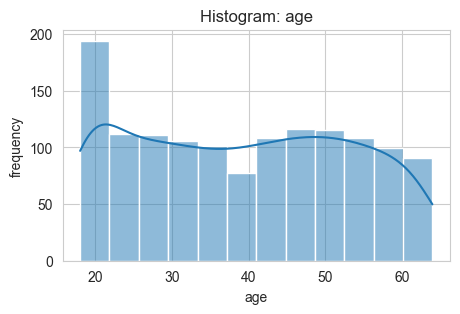

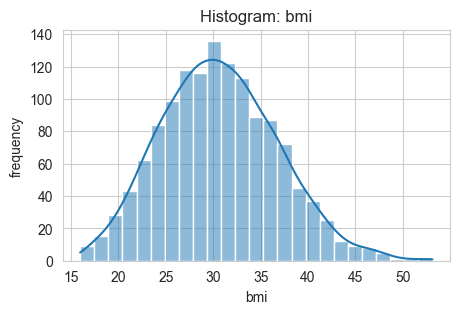

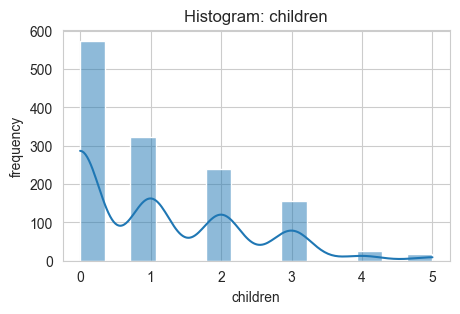

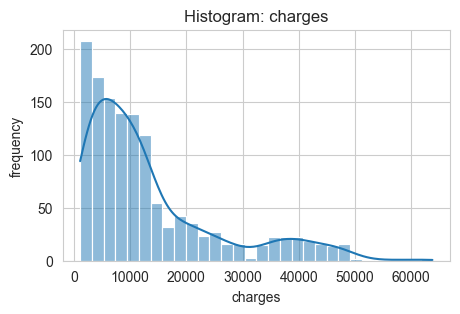

In [35]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.histplot(df[col],kde=True)
    plt.title(f"Histogram: {col}")
    plt.xlabel(col)
    plt.ylabel("frequency")
    plt.show()

we can skewness in children and charges columns

Box Plot-Outliers

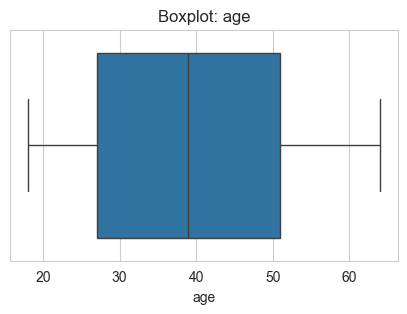

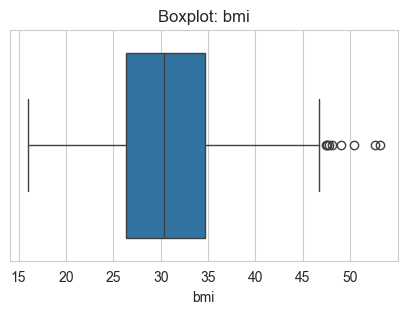

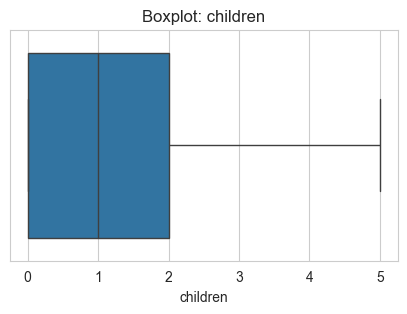

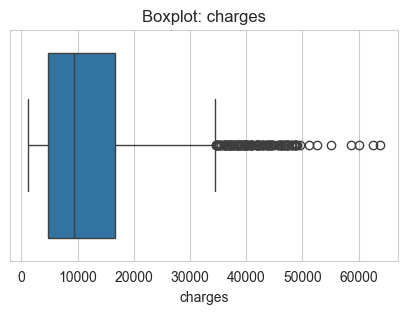

In [36]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot: {col}")
    plt.xlabel(col)
    plt.show()

Inference:

The 'charges' column contains significant outliers and is highly right-skewed. A few observations have very high values compared to the majority, which can affect model performance, especially for linear models. To handle this, techniques like log transformation or outlier treatment should be applied. These extreme values may represent real cases, so they should be handled carefully.

Categorical Analysis

In [37]:
print(cat_cols)

['sex', 'smoker', 'region']


Frequency Table

In [38]:
for col in cat_cols:
    print(f"Frequency table for {col} ")
    print(df[col].value_counts())
    print(f"Proportion for {col}")
    print(df[col].value_counts(normalize=True))
    print()

Frequency table for sex 
sex
male      676
female    662
Name: count, dtype: int64
Proportion for sex
sex
male     0.505
female   0.495
Name: proportion, dtype: float64

Frequency table for smoker 
smoker
no     1064
yes     274
Name: count, dtype: int64
Proportion for smoker
smoker
no    0.795
yes   0.205
Name: proportion, dtype: float64

Frequency table for region 
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64
Proportion for region
region
southeast   0.272
southwest   0.243
northwest   0.243
northeast   0.242
Name: proportion, dtype: float64



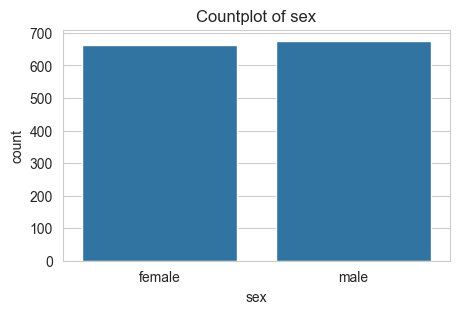

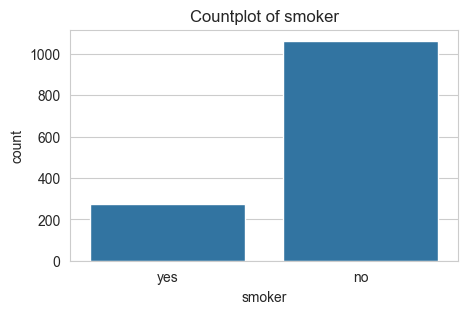

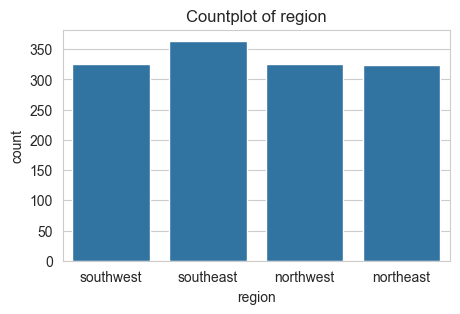

In [39]:
for col in cat_cols:
    plt.figure(figsize=(5,3))
    sns.countplot(x=df[col])
    plt.title(f"Countplot of {col}")
    plt.xlabel(col)
    plt.ylabel("count")

## Bivariate Analysis

Scatter plot

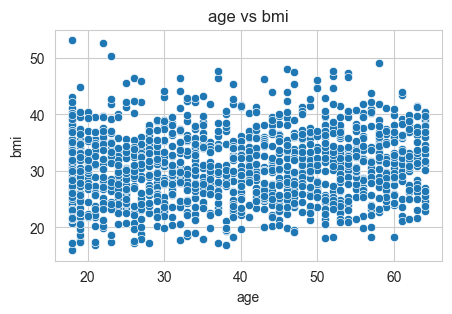

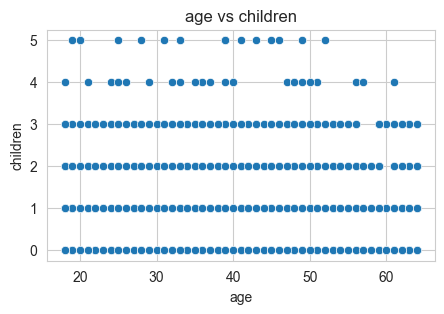

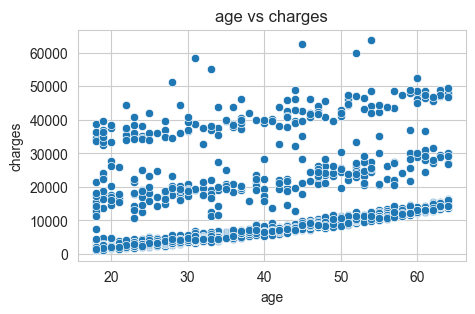

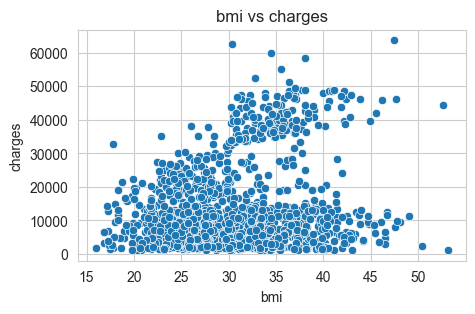

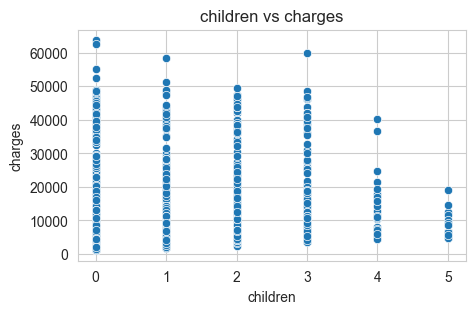

In [40]:
num_pairs=[
    ("age","bmi"),
    ("age","children"),
    ("age","charges"),
    ("bmi","charges"),
    ("children","charges")
]
for a,b in num_pairs:
    plt.figure(figsize=(5,3))
    sns.scatterplot(x=df[a],y=df[b])
    plt.title(f"{a} vs {b}")
    plt.xlabel(a)
    plt.ylabel(b)
    plt.show()

Inference:

There is a slight positive correlation between age and charges, and between BMI and charges. This indicates that as age and BMI increase, medical charges tend to increase, although the relationship is not very strong.

Correlation matrix

In [41]:
print(f"Correlation matrix")
df[num_cols].corr()


Correlation matrix


,age,bmi,children,charges
age,1.000,0.109,0.042,0.299
bmi,0.109,1.000,0.013,0.198
children,0.042,0.013,1.000,0.068
charges,0.299,0.198,0.068,1.000


In [42]:
print("Pearson Correlation with fare")
for col in num_cols:
    if col!="age":
        r,p=pearsonr(df[col],df['age'])
        print(f"{col} vs age: r={r:.3f}; p={p:.3f}")

Pearson Correlation with fare
bmi vs age: r=0.109; p=0.000
children vs age: r=0.042; p=0.120
charges vs age: r=0.299; p=0.000


Numerical and categorical features
